# Exercise 2: MNIST Dense Classification — Solution

In this exercise, you will build a **fully connected (dense) neural network** to classify handwritten digits from the [MNIST dataset](http://yann.lecun.com/exdb/mnist/).

You will learn:
- How to load and inspect image datasets with `torchvision`
- How to define a multi-layer perceptron (MLP) using `nn.Module`
- How to write a training loop with forward pass, loss computation, and backpropagation
- How to evaluate model performance on a test set
- How to implement validation-based model checkpointing (saving the "best" model)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision

# **1. Parameter Initialization and Data Preparation**

The MNIST dataset contains 60,000 training and 10,000 test images of handwritten digits (0–9), each 28×28 pixels in grayscale.

We apply two transforms:
- `ToTensor()`: converts PIL images to PyTorch tensors with values in [0, 1]
- `Normalize(0.5, 0.5)`: rescales pixel values to [-1, 1], which helps training converge faster

A `DataLoader` wraps the dataset and provides **mini-batch iteration** with optional shuffling.

In [2]:
# Parameters
batch_size = 4
num_epochs = 10
device = 'cuda:0'
num_classes = 10

# Load dataset
transform = torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
     torchvision.transforms.Normalize((0.5), (0.5))])

trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False,
                                       download=True, transform=transform)
classes = ('0', '1', '2', '3', '4', '5', '6', '7', '8', '9')

print(trainset)

# Create dataloaders
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=0.5, std=0.5)
           )


# **2. Visualize Sample Images**

Always inspect a few samples before training to verify the data pipeline is correct. The `imshow` function reverses the normalization so images display with the original pixel intensities.

In [3]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize to show images correctly
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

torch.Size([4, 1, 28, 28])


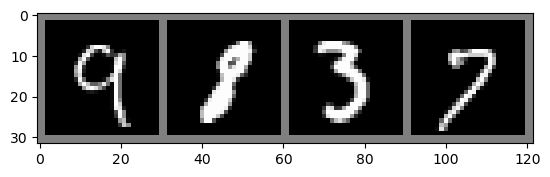

    9     8     3     7


In [4]:
# Print some samples of dataset as a sanity check

# Get some random training images
dataiter = iter(trainloader)
example_images, example_labels = next(dataiter)

print(example_images.shape)

# Show images
imshow(torchvision.utils.make_grid(example_images))
# Print labels
print(' '.join('%5s' % classes[example_labels[j]] for j in range(batch_size)))

# **3. Define Model**

Build a dense (fully connected) neural network by subclassing `nn.Module`. Your model must implement:
- `__init__()`: define the layers (e.g., `nn.Linear`) and their sizes
- `forward()`: define how data flows through the layers

Since MNIST images are 28×28 = 784 pixels, we first **flatten** each image into a 1D vector, then pass it through several dense layers with ReLU activations. The final layer outputs 10 logits (one per digit class).

Architecture: `784 → 512 → 256 → 64 → 10`

**Note:** We don't apply softmax at the end because `CrossEntropyLoss` already includes it internally.

In [5]:
class DenseNet(nn.Module):
    def __init__(self, input_features, num_classes):
        # Instantiation of layers and creation of trainable parameters
        super().__init__()
        self.flatten = nn.Flatten()
        self.dense1 = nn.Linear(input_features, 512)
        self.dense2 = nn.Linear(512, 256)
        self.dense3 = nn.Linear(256, 64)
        self.dense4 = nn.Linear(64, num_classes)

    def forward(self, x):
        # Forward pass: the computations that are done on the input -> output
        x = self.flatten(x)
        x = F.relu(self.dense1(x))
        x = F.relu(self.dense2(x))
        x = F.relu(self.dense3(x))
        x = self.dense4(x)
        return x

# **4. Training Loop**

The training loop repeats these steps for each mini-batch:
1. **Forward pass:** compute predictions (logits) from the model
2. **Loss computation:** compare predictions to ground-truth labels using `CrossEntropyLoss`
3. **Backward pass:** compute gradients via `loss.backward()`
4. **Parameter update:** adjust weights via `optimizer.step()`

`CrossEntropyLoss` internally applies softmax + negative log-likelihood, which is why the model outputs raw logits.

**Important:** Always call `optimizer.zero_grad()` before `loss.backward()` to clear gradients from the previous step.

In [6]:
def compute_run_acc(logits, labels):
    _, pred = torch.max(logits.data, 1)
    return (pred == labels).sum().item()

In [7]:
# Instantiate model and optimizer

model = DenseNet(784, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# Training loop
for epoch_nr in range(num_epochs):

    running_loss = 0.0
    running_acc = 0.0
    for batch_data, batch_labels in trainloader:

        # Put data on device
        batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)

        # Predict and get loss
        logits = model(batch_data)
        loss = criterion(logits, batch_labels)

        # Update model
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_acc += compute_run_acc(logits, batch_labels)
      
    # Print results
    print('TRAIN: Epoch {} completed | tr_loss: {:.4f} | tr_acc: {:.2f}%'.format(
        epoch_nr, running_loss/len(trainloader.dataset), 
        100 * running_acc/len(trainloader.dataset)))
    
    # Save model
    torch.save(model.state_dict(), './cifar_net.pth')
print('Finished Training')

TRAIN: Epoch 0 completed | tr_loss: 0.0905 | tr_acc: 88.62%
TRAIN: Epoch 1 completed | tr_loss: 0.0370 | tr_acc: 95.38%
TRAIN: Epoch 2 completed | tr_loss: 0.0263 | tr_acc: 96.68%
TRAIN: Epoch 3 completed | tr_loss: 0.0209 | tr_acc: 97.37%
TRAIN: Epoch 4 completed | tr_loss: 0.0170 | tr_acc: 97.84%
TRAIN: Epoch 5 completed | tr_loss: 0.0141 | tr_acc: 98.16%
TRAIN: Epoch 6 completed | tr_loss: 0.0122 | tr_acc: 98.44%
TRAIN: Epoch 7 completed | tr_loss: 0.0106 | tr_acc: 98.58%
TRAIN: Epoch 8 completed | tr_loss: 0.0087 | tr_acc: 98.86%
TRAIN: Epoch 9 completed | tr_loss: 0.0077 | tr_acc: 98.96%
Finished Training


# **5. Evaluate on Test Set**

After training, evaluate the model on data it has **never seen** during training. We use `torch.no_grad()` to disable gradient computation, which saves memory and speeds up inference.

The test accuracy tells us how well the model **generalizes** beyond the training data.

In [8]:
# Test loop
running_acc = 0
with torch.no_grad():
    for batch_data, batch_labels in testloader:
        batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)
        logits = model(batch_data)
        running_acc += compute_run_acc(logits, batch_labels)

print('TEST: test_acc: {:.2f}%'.format( 100 * running_acc/len(testloader.dataset)))

TEST: test_acc: 97.47%


# **6. Training Loop with Validation**

Instead of saving the model from the last epoch (which may have started overfitting), we save the model that achieves the **highest accuracy on a validation set**.

At each epoch:
1. Train on the training set
2. Evaluate on the validation/test set (without gradients)
3. If the current test accuracy is the best so far → save the model checkpoint

As this predefined dataset contains only 2 partitions, we use the test set as validation. In practice, you should always validate on a **separate** set from the test set when available.

In [ ]:
# Instantiate model and optimizer

model = DenseNet(784, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
best_test_acc = 0

tr_accuracies = np.zeros(num_epochs)
test_accuracies = np.zeros(num_epochs)

for epoch_nr in range(num_epochs):

    # Train model
    running_loss = 0.0
    running_acc = 0.0
    for batch_data, batch_labels in trainloader:

        # Put data on device
        batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)

        # Predict and get loss
        logits = model(batch_data)
        loss = criterion(logits, batch_labels)

        # Update model
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_acc += compute_run_acc(logits, batch_labels)
      
    # Print results
    tr_acc = 100 * running_acc/len(trainloader.dataset)
    print('TRAIN: Epoch {} completed | tr_loss: {:.4f} | tr_acc: {:.2f}%'.format(
        epoch_nr, running_loss/len(trainloader.dataset), tr_acc))
    tr_accuracies[epoch_nr] = tr_acc
    
    # Get testing results
    running_acc = 0
    with torch.no_grad():
        for batch_data, batch_labels in testloader:
            batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)
            logits = model(batch_data)
            running_acc += compute_run_acc(logits, batch_labels)

    test_acc = 100 * running_acc/len(testloader.dataset)
    print('TEST: Epoch {} | test_acc: {:.2f}%'.format(epoch_nr, test_acc))
    test_accuracies[epoch_nr] = test_acc

    # Save model if best accuracy on test dataset until now
    if test_acc > best_test_acc:
      best_test_acc = test_acc
      torch.save(model.state_dict(), './cifar_net.pth')
      print('Epoch {} : Model saved'.format(epoch_nr))

print('Finished Training')

TRAIN: Epoch 0 completed | tr_loss: 0.0914 | tr_acc: 88.21%
TEST: Epoch 0 | test_acc: 94.84%
Epoch 0 : Model saved
TRAIN: Epoch 1 completed | tr_loss: 0.0367 | tr_acc: 95.39%
TEST: Epoch 1 | test_acc: 96.28%
Epoch 1 : Model saved
TRAIN: Epoch 2 completed | tr_loss: 0.0265 | tr_acc: 96.61%
TEST: Epoch 2 | test_acc: 96.90%
Epoch 2 : Model saved
TRAIN: Epoch 3 completed | tr_loss: 0.0205 | tr_acc: 97.41%
TEST: Epoch 3 | test_acc: 96.76%
TRAIN: Epoch 4 completed | tr_loss: 0.0172 | tr_acc: 97.88%
TEST: Epoch 4 | test_acc: 96.07%
TRAIN: Epoch 5 completed | tr_loss: 0.0144 | tr_acc: 98.16%
TEST: Epoch 5 | test_acc: 97.51%
Epoch 5 : Model saved
TRAIN: Epoch 6 completed | tr_loss: 0.0123 | tr_acc: 98.40%
TEST: Epoch 6 | test_acc: 97.65%
Epoch 6 : Model saved
TRAIN: Epoch 7 completed | tr_loss: 0.0103 | tr_acc: 98.59%
TEST: Epoch 7 | test_acc: 97.54%
TRAIN: Epoch 8 completed | tr_loss: 0.0095 | tr_acc: 98.71%
TEST: Epoch 8 | test_acc: 97.77%
Epoch 8 : Model saved


# **7. Visualize Training Curves**

Plotting training and test accuracy across epochs reveals:
- **Underfitting:** both curves are low → model is too simple or training is too short
- **Overfitting:** training accuracy keeps rising but test accuracy plateaus or drops → model memorizes instead of generalizing
- **Good fit:** both curves converge to high values close together

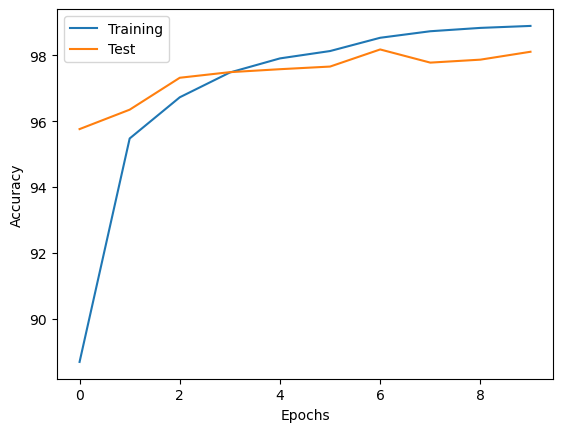

In [ ]:
plt.figure()
plt.plot(tr_accuracies, label='Training')
plt.plot(test_accuracies, label='Test')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.show()